# Industrial Defect Detection using Convolutional Neural Networks (CNN)

## Project Overview

This project aims to automatically classify surface defects on steel products using Computer Vision and Deep Learning.

The model was trained on the NEU-DET dataset containing six categories of industrial defects:

- Crazing
- Inclusion
- Patches
- Pitted Surface
- Rolled-in Scale
- Scratches

Technologies:
- Python
- TensorFlow / Keras
- Google Colab

Final Validation Accuracy: 90.8%

## 1. Dataset Preparation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/NEU-DET.zip"
extract_path = "/content/NEU-DET"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset décompressé avec succès.")

Dataset décompressé avec succès.


## 2. Dataset Exploration

In [ ]:
import os

classes = os.listdir("/content/NEU-DET/NEU-DET/train")

print("Classes trouvées :")
print(classes)

Classes trouvées :
['images', 'annotations']


In [ ]:
import os

base_path = "/content/NEU-DET/NEU-DET/train/images"

classes = os.listdir(base_path)

for cls in classes:
    n = len(os.listdir(os.path.join(base_path, cls)))
    print(f"{cls} : {n} images")

scratches : 240 images
crazing : 240 images
pitted_surface : 240 images
rolled-in_scale : 240 images
patches : 240 images
inclusion : 240 images


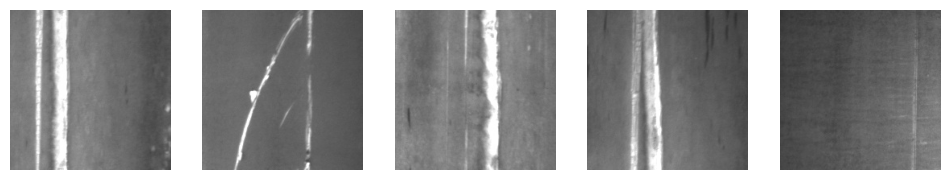

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

class_name = "scratches"

folder = f"/content/NEU-DET/NEU-DET/train/images/{class_name}"

images = os.listdir(folder)

plt.figure(figsize=(12,4))

for i in range(5):
    img = Image.open(os.path.join(folder, images[i]))

    plt.subplot(1,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.show()

In [ ]:
from PIL import Image
import os

img_path = "/content/NEU-DET/NEU-DET/train/images/scratches/" + images[0]

img = Image.open(img_path)

print("Dimensions :", img.size)

Dimensions : (200, 200)


## 3. Data Loading

In [ ]:
import tensorflow as tf

train_dir = "/content/NEU-DET/NEU-DET/train/images"
val_dir = "/content/NEU-DET/NEU-DET/validation/images"

img_size = (200, 200)
batch_size = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    label_mode="categorical"
)

val_data = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    label_mode="categorical"
)

print("Classes :", train_data.class_names)

Found 1440 files belonging to 6 classes.
Found 360 files belonging to 6 classes.
Classes : ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


## 4. CNN Architecture

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(200, 200, 1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,760,710 (33.42 MB)

 Trainable params: 8,760,710 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Model Training

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.2875 - loss: 1.6180 - val_accuracy: 0.3667 - val_loss: 1.2079
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 131s 3s/step - accuracy: 0.6132 - loss: 1.0367 - val_accuracy: 0.7417 - val_loss: 0.7974
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.7778 - loss: 0.6195 - val_accuracy: 0.5556 - val_loss: 1.1979
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - accuracy: 0.8194 - loss: 0.4991 - val_accuracy: 0.8611 - val_loss: 0.4388
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.8986 - loss: 0.2968 - val_accuracy: 0.8278 - val_loss: 0.5644
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.8917 - loss: 0.2945 - val_accuracy: 0.8917 - val_loss: 0.3158
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.9333 - loss: 0.2266 - val_accuracy: 0.8722 - val_loss: 0.3089
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.9222 - loss: 0.2316 - val_accuracy: 0.8333 - v

## 6. Model Evaluation

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 908ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 811ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
Rapport de classification :
                 precision    recall  f1-score   support

        crazing       0.98      1.00      0.99        60
      inclusion       0.95      0.68      0.80        60
        patches       1.00      0.98      0.99        60
 pitted_surface       0.73      0.95      0.83        60
rolled-in_scale       0.90      1.00      0.94        60
      scratches       0.96      0.83      0.89        60

       accuracy                           0.91       360
      macro avg       0.92      0.91      0.91       360
   weighted a

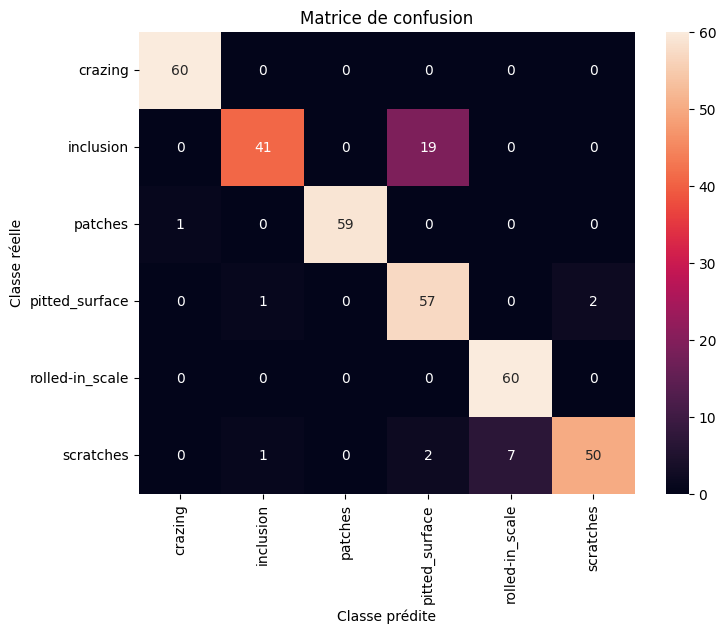

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Récupérer les vraies classes et les prédictions
y_true = []
y_pred = []

for images_batch, labels_batch in val_data:
    predictions = model.predict(images_batch)

    y_true.extend(np.argmax(labels_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

class_names = train_data.class_names

# Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true, y_pred, target_names=class_names))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion")
plt.show()

## Results

The trained CNN achieved the following performance:

- Training Accuracy: 95.8%
- Validation Accuracy: 90.8%
- Number of classes: 6
- Dataset size: 1,800 images

The confusion matrix shows that the model performs very well on classes such as crazing, patches, and rolled-in scale. Some confusion appears between inclusion and pitted surface defects.

## 7. Defect Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


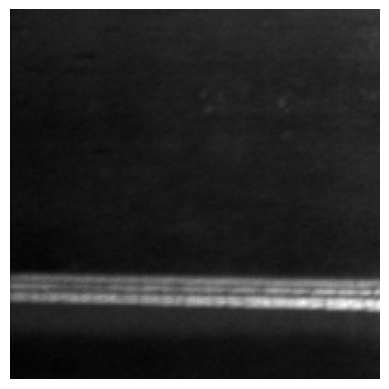

Défaut détecté : scratches
Confiance : 99.6 %


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

class_names = train_data.class_names

img_path = "/content/NEU-DET/NEU-DET/validation/images/scratches/" + \
           os.listdir("/content/NEU-DET/NEU-DET/validation/images/scratches")[0]

img = image.load_img(
    img_path,
    color_mode='grayscale',
    target_size=(200,200)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

print("Défaut détecté :", predicted_class)
print("Confiance :", round(confidence,2), "%")

In [ ]:
model.save("modele_defauts_NEU.keras")

print("Modèle sauvegardé avec succès")

Modèle sauvegardé avec succès


## Conclusion

This project demonstrates the use of Computer Vision for industrial quality control.

The developed CNN model is able to classify six types of steel surface defects with a validation accuracy of approximately 91%.

Future improvements may include:
- using transfer learning models such as MobileNetV2 or ResNet50,
- adding a normal/no-defect class for true Go/No-Go inspection,
- building a web interface for real-time image testing,
- using object detection to localize defects on the surface.